In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from tqdm.notebook import tqdm
import scipy
import sklearn

### Load data

In [21]:
cwd = Path('.')
data_path = cwd / 'data' / '2025_LoL_esports_match_data_from_OraclesElixir.csv'
data: pd.DataFrame = pd.read_csv(data_path)
data = data.iloc[:int(len(data)*0.11 / 12) * 12] # 10% of data for testing to make code run faster - must be divisible by 12 since each match has 12 rows
data_len = int(len(data) * 10 / 12)

C:\Users\dwarf\AppData\Local\Temp\ipykernel_10272\376905083.py:3: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  data: pd.DataFrame = pd.read_csv(data_path)


### Duplicating data and removing surplus rows

The data consists of rows of match statistics for specific players. 

Since each match has 2 teams of 5 players, you would expect 10 rows for each match. It turns out that there are 12 rows for each match because there are 2 extra rows that contain information about the team as a whole, rather than the players. 

Since we want to analyze the players, we take the teamwide information contained in these 2 rows (which is simply missing information in the player rows) and duplicate it to the player rows of those teams in the places that the players are missing data (if present in the team data). 

In [25]:
for matchid in tqdm(data["gameid"].unique()):
    game = data[data["gameid"] == matchid]
    teams = game["teamid"].unique()

    for teamid in teams:
        team = game[game["teamid"] == teamid]

        players = team[team["position"] != "team"]
        team_stats = team[team["position"] == "team"]

        # fill missing values in players with team stats if available
        for column in data.columns:
            if players[column].isnull().any():
                data.loc[players.index, column] = team_stats[column].item()

  0%|          | 0/1105 [00:00<?, ?it/s]

We then drop all rows that only contain teamwide statistics, as we are interested only in the player performances

In [27]:
data = data.drop(data[data["position"] == "team"].index) 

### Clean data for missing data and unrelated columns

Currently the data is full of missing values as can be seen on the missing value plot below, so we remove the the columns that have many missing values and then the rows that have many missing values. 

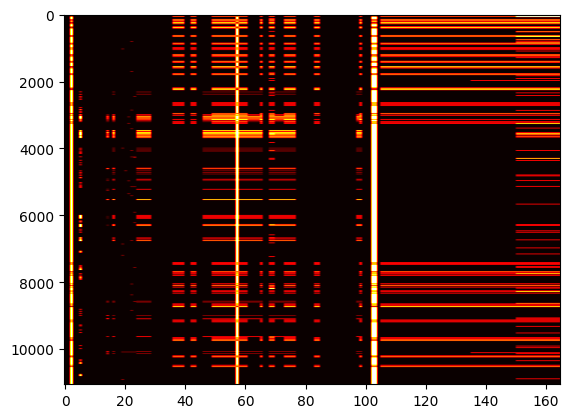

In [28]:
plt.imshow(data.isnull(), cmap='hot', aspect='auto')
plt.show()

In [29]:

# drop columns with more than a given percentage of missing values
missing_value_column_percentage_threshold = 0.05
missing_values = data.isnull().sum()
missing_value_columns = missing_values[missing_values > len(data) * missing_value_column_percentage_threshold].index
data = data.drop(columns=missing_value_columns)

# drop 10-rows (matches) with more than a given percentage of missing values
missing_value_row_percentage_threshold = 0
z = data.isnull().sum(axis=1)
gameids = data[z > len(data.columns) * missing_value_row_percentage_threshold]["gameid"].unique()

data = data.drop(data[data["gameid"].isin(gameids)].index)

The remaining data no longer contains a large amount of missing data as can be seen on the graph below, and still has 

In [30]:
100 * len(data) / data_len

89.86425339366515

In [31]:
len(data) / 10

993.0

% of the data rows

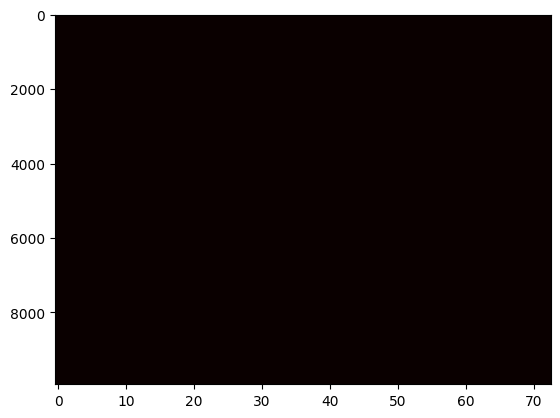

In [32]:
plt.imshow(data.isnull(), cmap='hot', aspect='auto')
plt.show()

### Modelling categorical variables as multivariate bernoulli variables (one-hot encoding)

In [33]:
# drop irrelevant columns
data_pure = data.drop(columns=["gameid", "datacompleteness", "league", "year", "playoffs", "date", "game", "patch", "participantid", "playername", "playerid", "teamname", "teamid"])

In [34]:
# convert categorical columns to one-hot encoding
data_numeric = pd.get_dummies(data_pure, dtype=float)
X = data_numeric.to_numpy()
X.shape

(9930, 1248)

### Normalize data and calculate covariance and correlation matrix

In [35]:
X_mean = np.mean(X, axis=0)                     # 1 / (X.shape[0]) * X.T @ np.ones(X.shape[0])

# calculate the zero-centered data matrix and the covariance matrix
X_centered = X - X_mean                         # X - np.ones((X.shape[0, 1])) @ X_mean[np.newaxis, :]
X_cov = np.cov(X_centered, rowvar=False)        # 1 / (X_centered.shape[0]) * (X_centered.T @ X_centered)

# calculate the standard score normalized matrix and the correlation matrix
X_normalized = scipy.stats.zscore(X, axis=1)    # (x - mean) / std
X_cor = np.cov(X_normalized, rowvar=False)      # 1 / (X_normalized.shape[0]) * (X_normalized.T @ X_normalized)

###  Clustering of known quantity

Can we make a clustering of player match statistics that clusters each match statistic into one of the 5 league of legends roles (Top / Jungle / Mid / Bottom / Support)?

We use k-means clustering with $k=5$. 

We need to remove the one-hot encoded player role ("position" column) from the data, as this is what we are hoping to determine with our clustering.

In [20]:
position_indexes = np.where(("position_top" == data_numeric.columns) | ("position_jng" == data_numeric.columns) | ("position_mid" == data_numeric.columns) | ("position_bot" == data_numeric.columns) | ("position_sup" == data_numeric.columns))
X_hat = X_normalized
X_hat_no_position = np.delete(X_hat, position_indexes, axis=1)
X_cor_no_position = np.cov(X_hat_no_position, rowvar=False)

In [82]:
clustering = sklearn.cluster.KMeans(n_clusters=5).fit(X_hat_no_position)

c:\Users\dwarf\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


We can now look at the clusters to see if each cluster is represented by a position

In [103]:
for i in range(5):
    print(f"Cluster {i}:")
    print(data_pure["position"].iloc[np.where(clustering.labels_ == i)[0]].value_counts())
    print("\n")

Cluster 0:
position
mid    811
bot    805
top    642
jng    435
sup     78
Name: count, dtype: int64


Cluster 1:
position
sup    880
jng    194
top     55
mid     12
bot      8
Name: count, dtype: int64


Cluster 2:
position
mid    637
bot    583
top    334
jng    116
sup     17
Name: count, dtype: int64


Cluster 3:
position
sup    782
jng    572
top    316
bot    113
mid    104
Name: count, dtype: int64


Cluster 4:
position
jng    669
top    639
bot    477
mid    422
sup    229
Name: count, dtype: int64




Since our clustering ended up being quite poor, we can try to do a PCA dimensionality reduction to 2 dimensions and see if our data is clearly separable by position

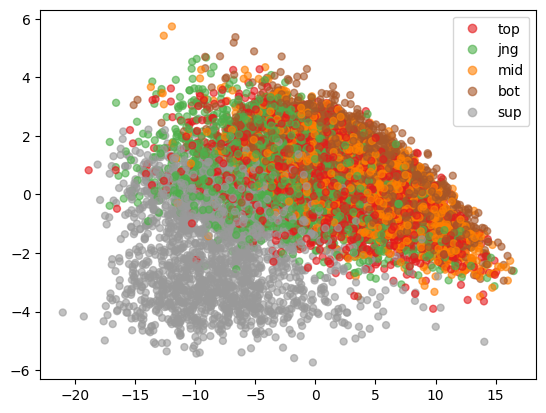

In [174]:
# plot pca with position as color
pca = sklearn.decomposition.PCA(n_components=2).fit(X_hat_no_position)
X_pca = pca.transform(X_hat_no_position)
z = {"top": 0, "jng": 1, "mid": 2, "bot": 3, "sup": 4}
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=data_pure["position"].apply(lambda x: z[x]), cmap="Set1", s=25, alpha=0.6)
handles, labels = scatter.legend_elements()
labels = ["top", "jng", "mid", "bot", "sup"]
plt.legend(handles, labels)
plt.show()

Which turns out not to be the case, except for support

### Clustering of unknown quantity

We are also interested in finding out if there is some pattern in the players perfomance, are there clear clusters showing potential different types of perfomance, EG a average performance, above average, below average. Yet unlike above there is no base truth that we can compare it to so it makes more sense to use clustering density clustering algorithmns like DBSCAN to try and find clusters of perfomances that are similar to eachother.

Ideally we want points that are somewhat close, but we want a relatively high MinPts since we are looking to find more generalized clusters rather than highly specific clusters

In [ ]:
X_hat = X_normalized


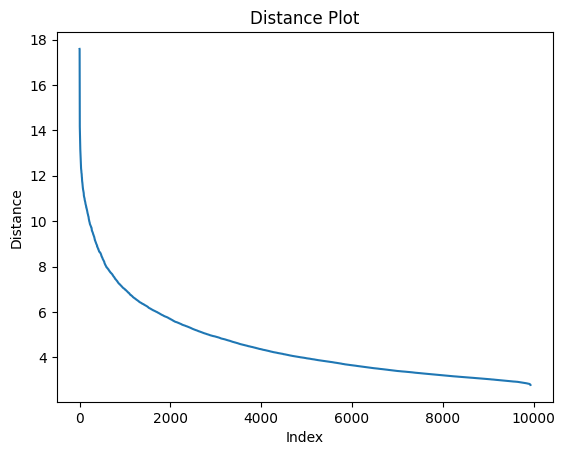

In [83]:
neighbors = 2*X_hat.shape[1]
nbrs = sklearn.neighbors.NearestNeighbors(n_neighbors=neighbors ).fit(X_hat)
distances, indices = nbrs.kneighbors(X_hat)
distance_desc = sorted(distances[:,neighbors-1], reverse=True)
plt.plot(
    range(1, len(distance_desc) + 1),
    distance_desc
)

plt.xlabel("Index")
plt.ylabel("Distance")
plt.title("Distance Plot")

plt.show()

In [ ]:
density_cluster = sklearn.cluster.DBSCAN(eps=5, min_samples = neighbors).fit(X_hat)

In [ ]:
labels = np.unique(density_cluster.labels_)
labels

We see using this method we only get one cluster, which is not entirely surprising considering the very high dimensionality of the data which is causing min pts to be very large based on the heuristic. To try to alleviate this we cna use PCA to reduce dimensionality to hopefully improve the results.

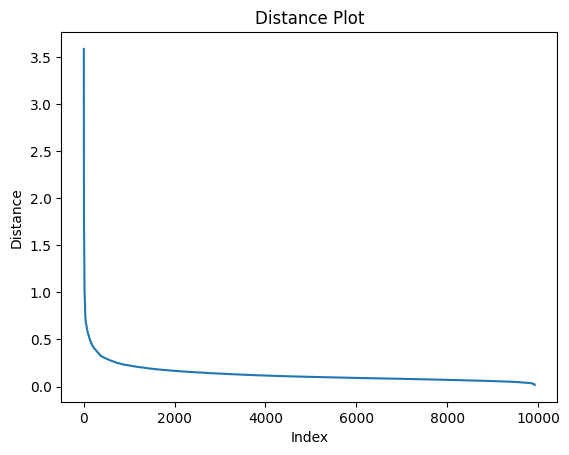

In [ ]:
pca = sklearn.decomposition.PCA(n_components=2).fit(X_hat)
X_pca = pca.transform(X_hat)

neighbors = 2*X_pca.shape[1]
nbrs = sklearn.neighbors.NearestNeighbors(n_neighbors=neighbors ).fit(X_pca)
distances, indices = nbrs.kneighbors(X_pca)
distance_desc = sorted(distances[:,neighbors-1], reverse=True)
plt.plot(
    range(1, len(distance_desc) + 1),
    distance_desc
)

plt.xlabel("Index")
plt.ylabel("Distance")
plt.title("Distance Plot")

plt.show()

In [ ]:
density_cluster = sklearn.cluster.DBSCAN(eps=0.3, min_samples = neighbors).fit(X_pca)
labels = np.unique(density_cluster.labels_)
labels

array([-1,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13],
      dtype=int64)

Now we are seeing a few too many clusters due to the rule of thumb for min pts not really working well for this type of data, as we ideally want to group games fall into more broad clusters. So we will manually set min pts to 20.

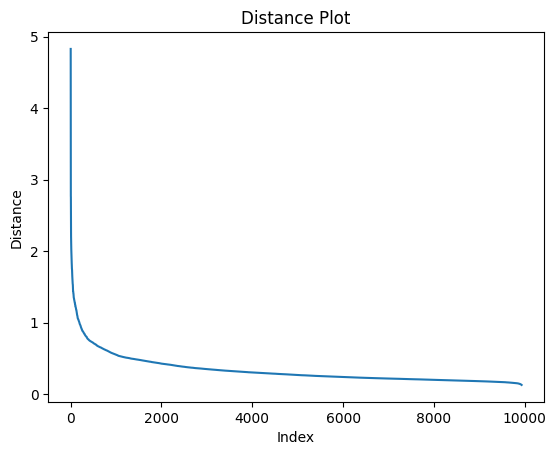

In [ ]:
neighbors = 20
nbrs = sklearn.neighbors.NearestNeighbors(n_neighbors=neighbors ).fit(X_pca)
distances, indices = nbrs.kneighbors(X_pca)
distance_desc = sorted(distances[:,neighbors-1], reverse=True)
plt.plot(
    range(1, len(distance_desc) + 1),
    distance_desc
)

plt.xlabel("Index")
plt.ylabel("Distance")
plt.title("Distance Plot")

plt.show()

In [ ]:
density_cluster = sklearn.cluster.DBSCAN(eps=0.6, min_samples = neighbors).fit(X_pca)
unique_labels = np.unique(density_cluster.labels_)
labels = density_cluster.labels_
unique_labels

array([-1,  0,  1,  2], dtype=int64)

In [81]:
label_counts = np.unique(labels, return_counts=True)
label_counts

(array([-1,  0,  1,  2], dtype=int64),
 array([ 426, 9473,   13,   18], dtype=int64))

Now we are getting a more reasonable 3 clusters, though one cluster is highly represented 

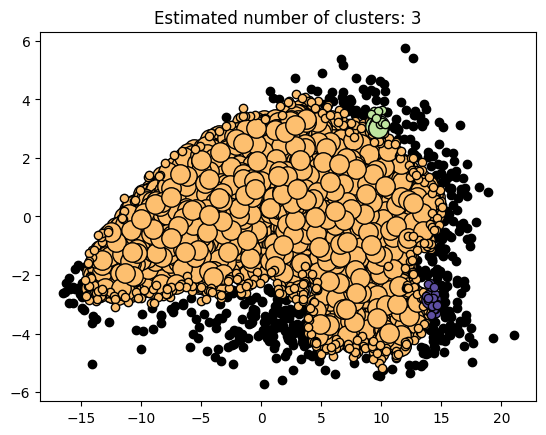

In [78]:
core_samples_mask = np.zeros_like(labels, dtype=bool)
core_samples_mask[density_cluster.core_sample_indices_] = True

colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black used for noise.
        col = [0, 0, 0, 1]

    class_member_mask = labels == k

    xy = X_pca[class_member_mask & core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=14,
    )

    xy = X_pca[class_member_mask & ~core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=6,
    )

plt.title(f"Estimated number of clusters: {len(unique_labels)-1}")
plt.show()

This can be read as that a vast perfomances being similar, though we should still try to investigate a bit further

We can try to use OPTICS instead since it is better suited for such high dimensional data